In [26]:
!pip install -U transformers accelerate bitsandbytes

In [27]:
import time
import torch
import matplotlib.pyplot as plt

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)

In [28]:
models = {
    "TinyLlama": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "Phi-2": "microsoft/phi-2"
}

prompts = [
    "Explain machine learning",
    "What is overfitting?",
    "Translate this to Uzbek: Hello world",
    "Write short story about AI"
]

results = {}

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [29]:
def test_model(model_name, model_id, quantization=None):
    print(f"\n Testing {model_name} | Quant: {quantization}")

    tokenizer = AutoTokenizer.from_pretrained(model_id)

    if quantization == "8bit":
        bnb_config = BitsAndBytesConfig(load_in_8bit=True)

        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=bnb_config,
            device_map="auto"
        )

    elif quantization == "4bit":
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16
        )

        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=bnb_config,
            device_map="auto"
        )

    else:
        model = AutoModelForCausalLM.from_pretrained(model_id).to(device)

    model.eval()

    total_time = 0
    total_tokens = 0

    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        start = time.time()

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=100
            )

        end = time.time()

        elapsed = end - start
        tokens = outputs.shape[1]

        total_time += elapsed
        total_tokens += tokens

    avg_time = total_time / len(prompts)
    tokens_per_sec = total_tokens / total_time

    print(f" Avg Time: {avg_time:.2f}s")
    print(f" Tokens/sec: {tokens_per_sec:.2f}")

    return avg_time, tokens_per_sec

In [30]:
for name, model_id in models.items():
    results[name] = {}

    t, s = test_model(name, model_id)
    results[name]["FP32"] = (t, s)

    torch.cuda.empty_cache()

    t, s = test_model(name, model_id, "8bit")
    results[name]["INT8"] = (t, s)

    torch.cuda.empty_cache()

    t, s = test_model(name, model_id, "4bit")
    results[name]["INT4"] = (t, s)

    torch.cuda.empty_cache()


 Testing TinyLlama | Quant: None


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

 Avg Time: 1.13s
 Tokens/sec: 15.74

 Testing TinyLlama | Quant: 8bit


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


 Avg Time: 11.49s
 Tokens/sec: 7.38

 Testing Phi-2 | Quant: 4bit


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


 Avg Time: 5.24s
 Tokens/sec: 20.13


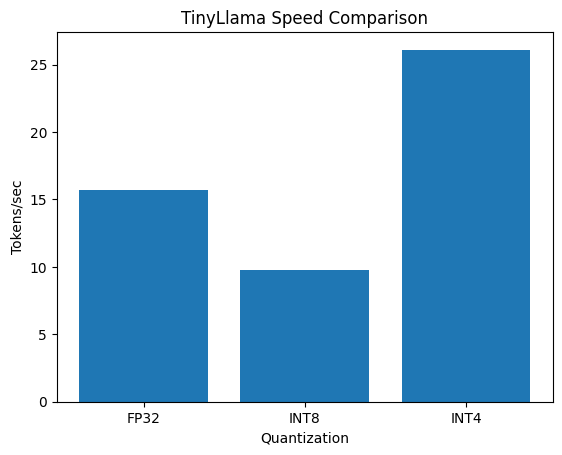

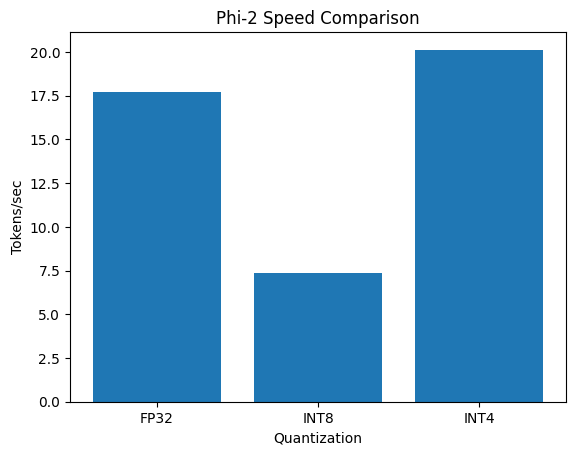

In [31]:
for model in results:
    variants = list(results[model].keys())
    speeds = [results[model][v][1] for v in variants]

    plt.figure()
    plt.bar(variants, speeds)
    plt.title(f"{model} Speed Comparison")
    plt.xlabel("Quantization")
    plt.ylabel("Tokens/sec")
    plt.show()

In [32]:
print("\n FINAL RESULTS:")
for model in results:
    print(f"\nModel: {model}")
    for variant in results[model]:
        t, s = results[model][variant]
        print(f"{variant} -> Time: {t:.2f}s | Speed: {s:.2f} tok/s")


 FINAL RESULTS:

Model: TinyLlama
FP32 -> Time: 1.13s | Speed: 15.74 tok/s
INT8 -> Time: 1.89s | Speed: 9.79 tok/s
INT4 -> Time: 1.34s | Speed: 26.11 tok/s

Model: Phi-2
FP32 -> Time: 4.59s | Speed: 17.69 tok/s
INT8 -> Time: 11.49s | Speed: 7.38 tok/s
INT4 -> Time: 5.24s | Speed: 20.13 tok/s
